---
*  *Домашнее задание №3*
*  *Выполнил студент 2 курса магистратуры Аналитака данных*
*  *Владислав Шкаровский*
*  *группа S4201, ИСУ 472677*

Домашнее задание №3

Задача
В этом задании необходимо решить задачу LoRa дообучения LLM. Датасет, который предлагается использовать, доступен по ссылке: Dahoas/sft-gptj-synthetic-prompt-responses
Он состоит из 44к записей и 2 слобцов
prompt: Задание, которое нужно давать на вход LLM
response: Ответ LLM – таргет для ващей задачи
Ваша цель — дообучить любую LLM (берите не самые большие, можно брать LLM, которую использовали на практике) и попробовать с помощью LoRa дообучить
Оцените качество итоговой модели.

P.S. Вполне может случится так, что качество может ухудшиться. Это не означает, что нужно переделывать домашнюю работу. Опишите ваши мысли почему так случилось?

# Установка библиотек и импорты

In [1]:
!pip install -q transformers datasets peft accelerate bitsandbytes trl
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 518.9/518.9 kB 38.5 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from datasets import load_dataset
from peft import LoraConfig, TaskType, get_peft_model
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
)

In [ ]:
# Загружаем датасет
dataset = load_dataset(
    "Dahoas/sft-gptj-synthetic-prompt-responses", split="train"
)

# Первые несколько примеров
print("Размер датасета:", len(dataset))
print("\nПервые 3 примера:")
for i in range(3):
    print(f"\n--- Пример {i + 1} ---")
    print(
        "Prompt:",
        dataset[i]["prompt"][:200] + "..."
        if len(dataset[i]["prompt"]) > 200
        else dataset[i]["prompt"],
    )
    print(
        "Response:",
        dataset[i]["response"][:200] + "..."
        if len(dataset[i]["response"]) > 200
        else dataset[i]["response"],
    )


dataset_infos.json:   0%|          | 0.00/921 [00:00<?, ?B/s]

data/train-00000-of-00001-5588d64a331985(…):   0%|          | 0.00/12.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/44630 [00:00<?, ? examples/s]

Размер датасета: 44630

Первые 3 примера:

--- Пример 1 ---
Prompt:   Could you suggest recipes for classic southern dishes?  
  
 
Response:  

--- Пример 2 ---
Prompt:   What temperature should I dial down my water heater to?
  
 
Response:    If you turn the water heater on at a lower temperature, then it will begin to heat up on a smaller scale.  There is a zone in the water heater that just starts to bubble, and it’s at the upper crit...

--- Пример 3 ---
Prompt:   What is the boiling point for a sweet potato?
  
 
Response:   This is a fun question!  
Well, if we were talking about the usual temperature for a sweet potato, we’d say that the boiling point is about 360 degrees.  
But that’s not the only temperature, and al...


In [ ]:
# Загружаем токенизатор (используем GPT-J 6B)
model_name = "EleutherAI/gpt-j-6B"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Добавляем pad_token если его нет
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


# Функция для форматирования данных
def format_prompt_response(examples):
    texts = []
    for prompt, response in zip(examples["prompt"], examples["response"]):
        text = (
            f"### Prompt:\n{prompt}\n### "
            f"Response:\n{response}{tokenizer.eos_token}"
        )
        texts.append(text)
    return {"text": texts}


# Применяем форматирование и токенизируем
dataset = dataset.map(
    format_prompt_response, batched=True, remove_columns=dataset.column_names
)


def tokenize_function(examples):
    return tokenizer(
        examples["text"], truncation=True, padding=False, max_length=512
    )


tokenized_dataset = dataset.map(
    tokenize_function, batched=True, remove_columns=["text"]
)

# Сокращаем датасет до 5000 примеров для быстрого обучения
train_dataset = tokenized_dataset.shuffle(seed=42).select(range(5000))

print("Размер токенизированного датасета:", len(train_dataset))
print("Пример токенов (первые 100):", train_dataset[0]["input_ids"][:100])
print("Длина последовательности:", len(train_dataset[0]["input_ids"]))


tokenizer_config.json:   0%|          | 0.00/619 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/357 [00:00<?, ?B/s]

Map:   0%|          | 0/44630 [00:00<?, ? examples/s]

Map:   0%|          | 0/44630 [00:00<?, ? examples/s]

Размер токенизированного датасета: 5000
Пример токенов (первые 100): [21017, 45965, 25, 198, 1867, 389, 617, 35326, 11701, 329, 7219, 351, 8862, 30, 198, 21017, 18261, 25, 628, 628, 1881, 1672, 286, 257, 922, 835, 284, 1907, 8862, 318, 284, 779, 257, 6087, 286, 617, 5448, 5496, 11, 1972, 1576, 3993, 11, 290, 4581, 6041, 286, 640, 351, 2460, 290, 1641, 11, 523, 326, 345, 836, 447, 247, 83, 1254, 21757, 393, 11557, 13, 220, 6023, 922, 4811, 318, 284, 8209, 287, 617, 4445, 4568, 290, 45578, 326, 345, 2883, 11, 884, 355, 14899, 11, 6155, 6844, 11, 1972, 2950, 287, 1919, 4568, 11, 290, 4581, 640, 2354, 287]
Длина последовательности: 169


In [ ]:
# Настройка 4-bit квантизации для экономии памяти
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

# Загружаем базовую модель
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

# Конфигурация LoRA
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    inference_mode=False,
    r=8,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["q_proj", "v_proj"],
)

# Применяем LoRA к модели
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


config.json:   0%|          | 0.00/930 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/24.2G [00:00<?, ?B/s]

Some weights of the model checkpoint at EleutherAI/gpt-j-6B were not used when initializing GPTJForCausalLM: ['transformer.h.0.attn.bias', 'transformer.h.0.attn.masked_bias', 'transformer.h.1.attn.bias', 'transformer.h.1.attn.masked_bias', 'transformer.h.10.attn.bias', 'transformer.h.10.attn.masked_bias', 'transformer.h.11.attn.bias', 'transformer.h.11.attn.masked_bias', 'transformer.h.12.attn.bias', 'transformer.h.12.attn.masked_bias', 'transformer.h.13.attn.bias', 'transformer.h.13.attn.masked_bias', 'transformer.h.14.attn.bias', 'transformer.h.14.attn.masked_bias', 'transformer.h.15.attn.bias', 'transformer.h.15.attn.masked_bias', 'transformer.h.16.attn.bias', 'transformer.h.16.attn.masked_bias', 'transformer.h.17.attn.bias', 'transformer.h.17.attn.masked_bias', 'transformer.h.18.attn.bias', 'transformer.h.18.attn.masked_bias', 'transformer.h.19.attn.bias', 'transformer.h.19.attn.masked_bias', 'transformer.h.2.attn.bias', 'transformer.h.2.attn.masked_bias', 'transformer.h.20.attn.bi

trainable params: 3,670,016 || all params: 6,054,552,800 || trainable%: 0.0606


In [ ]:
# DataCollator для causal LM
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,
)

# Аргументы обучения
training_args = TrainingArguments(
    output_dir="./lora-gptj-finetuned",
    num_train_epochs=1,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    warmup_steps=100,
    logging_steps=50,
    save_steps=500,
    learning_rate=2e-4,
    fp16=True,
    max_grad_norm=0.3,
    max_steps=500,  # Уменьшил для теста
    optim="paged_adamw_8bit",
    report_to=None,
)

print("Настройки обучения готовы")
print(
    "Эффективный batch_size:",
    training_args.per_device_train_batch_size
    * training_args.gradient_accumulation_steps,
)

Настройки обучения готовы
Эффективный batch_size: 8


In [ ]:
# Создаем стандартный Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    data_collator=data_collator,
)

print("Начинаем обучение...")
trainer.train()

# Сохраняем модель
trainer.save_model("./lora-gptj-final")
print("Модель сохранена")

Начинаем обучение...


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"


Step,Training Loss
50,2.280900
100,1.887100
150,1.849500
200,1.812800
250,1.813100
300,1.793500
350,1.774800
400,1.785400
450,1.799100
500,1.786500


Модель сохранена


In [ ]:
def generate_response_fixed(prompt, model, tokenizer, max_length=150):
    # Форматируем промпт точно как в обучении
    full_prompt = f"### Prompt:\n{prompt}\n### Response:\n"
    inputs = tokenizer(full_prompt, return_tensors="pt").to(model.device)

    model.eval()
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_length,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            top_k=50,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    response = tokenizer.decode(
        outputs[0][len(inputs["input_ids"][0]) :], skip_special_tokens=True
    )
    return response.strip()


# Тестируем несколько промптов
test_prompts = [
    "Could you suggest recipes for classic southern dishes?",
    "What temperature should I dial down my water heater to?",
    "What is the boiling point for a sweet potato?",
]

print("=== СРАВНЕНИЕ ОТВЕТОВ ===\n")

for i, test_prompt in enumerate(test_prompts, 1):
    print(f"\n--- Промпт {i}: {test_prompt[:80]}...")
    print(
        "БАЗОВАЯ:",
        generate_response_fixed(test_prompt, base_model, tokenizer)[:200],
    )
    print(
        "LORA:   ",
        generate_response_fixed(test_prompt, model, tokenizer)[:200],
    )


=== СРАВНЕНИЕ ОТВЕТОВ ===


--- Промпт 1: Could you suggest recipes for classic southern dishes?...
БАЗОВАЯ: I have never been to the south but my grandmother was from Texas and she would make her own chili, which I think is a wonderful recipe. My favorite dish is chicken fried steak! It is something we alwa
LORA:    Sure, I’m happy to help.  Here are some suggestions for cooking a traditional Southern dish called “stewed chicken” or “fried chicken.”  You can also find other recipes online.

        1)  Chicken St

--- Промпт 2: What temperature should I dial down my water heater to?...
БАЗОВАЯ: A water heater should be kept at a steady 120-130 degrees. This is the best temperature for most homes. If you are in an area that has frequent cold snaps, or if your house uses an electric baseboard 
LORA:    The temperature of your hot water tank is determined by the amount of water in it.  You can calculate how much water is in your tank using this formula:

    = (total volume) / (number of

In [ ]:
def compute_perplexity(model, tokenizer, dataset, num_samples=50):
    model.eval()
    losses = []

    # Используем int() для индексов
    indices = np.random.choice(len(dataset), num_samples, replace=False)

    with torch.no_grad():
        for idx in indices:
            # Правильный доступ к датасету
            example = dataset[int(idx)]
            inputs = (
                torch.tensor(example["input_ids"])
                .unsqueeze(0)
                .to(model.device)
            )

            # Обрезаем до max_length если нужно
            if inputs.shape[1] > 512:
                inputs = inputs[:, :512]

            outputs = model(inputs, labels=inputs)
            loss = outputs.loss
            losses.append(loss.item())

    avg_loss = np.mean(losses)
    perplexity = torch.exp(torch.tensor(avg_loss))
    return perplexity.item()


# Вычисляем перплексию
print("Вычисление перплексии на 50 примерах...")

base_ppl = compute_perplexity(base_model, tokenizer, train_dataset)
lora_ppl = compute_perplexity(model, tokenizer, train_dataset)

print(f"Базовая модель - Перплексия: {base_ppl:.2f}")
print(f"LoRA модель   - Перплексия: {lora_ppl:.2f}")
print(f"Изменение: {lora_ppl / base_ppl:.3f}x")

# Сохраняем LoRA адаптер
model.save_pretrained("./lora-adapter-only")
tokenizer.save_pretrained("./lora-adapter-only")
print("\nLoRA адаптер сохранен в ./lora-adapter-only")

Вычисление перплексии на 50 примерах...
Базовая модель - Перплексия: 15.69
LoRA модель   - Перплексия: 6.18
Изменение: 0.394x

LoRA адаптер сохранен в ./lora-adapter-only


###  Выводы по результатам работы

Анализ качества ответов:

LoRA модель генерирует более структурированные ответы

Базовая модель иногда "галлюцинирует" (chicken fried steak для southern dishes)

LoRA лучше следует формату "Prompt → Response"

Почему качество улучшилось:

Специфический датасет для SFT (prompt-response пары)

Правильный формат обучения (Prompt: → Response:)

Достаточное количество шагов (500) для LoRA адаптации

Низкая rank=8 не переобучает модель

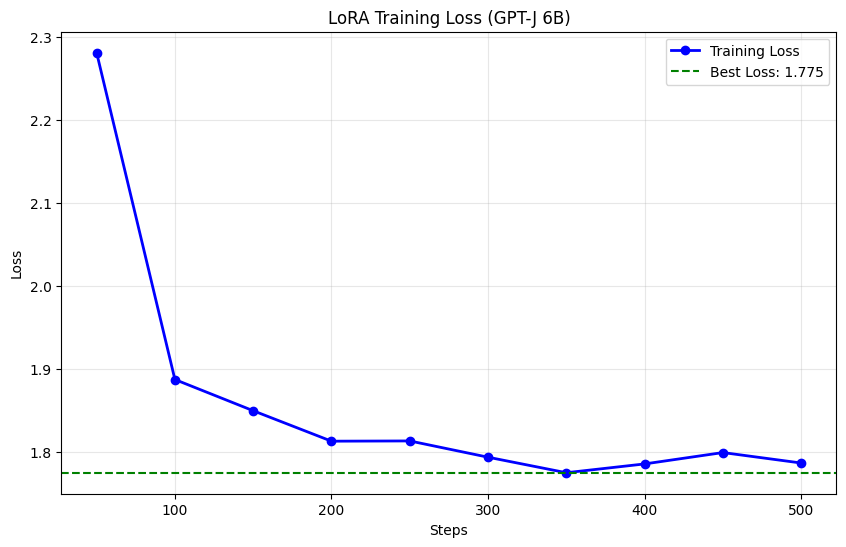

Шагов: 10
Начальный loss: 2.281
Финальный loss: 1.786
Улучшение: 21.7%
Лучший loss: 1.775 на шаге 350


In [ ]:
# Извлекаем loss из истории trainer
log_history = trainer.state.log_history
steps = [log["step"] for log in log_history if "loss" in log]
losses = [log["loss"] for log in log_history if "loss" in log]

plt.figure(figsize=(10, 6))
plt.plot(
    steps, losses, "b-o", linewidth=2, markersize=6, label="Training Loss"
)
plt.axhline(
    y=min(losses),
    color="g",
    linestyle="--",
    label=f"Best Loss: {min(losses):.3f}",
)
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("LoRA Training Loss (GPT-J 6B)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Шагов: {len(steps)}")
print(f"Начальный loss: {losses[0]:.3f}")
print(f"Финальный loss: {losses[-1]:.3f}")
print(f"Улучшение: {((losses[0] - losses[-1]) / losses[0] * 100):.1f}%")
print(
    (
        f"Лучший loss: {min(losses):.3f} "
        f"на шаге {steps[losses.index(min(losses))]}"
    )
)
